Using device: cpu
Directories created: artifacts/figures
Number of observations: 4320
Date range: 2025-01-01 00:00:00 — 2025-06-29 23:00:00
Frequency: 0 days 01:00:00

Missing values:
 date      0
target    0
dtype: int64


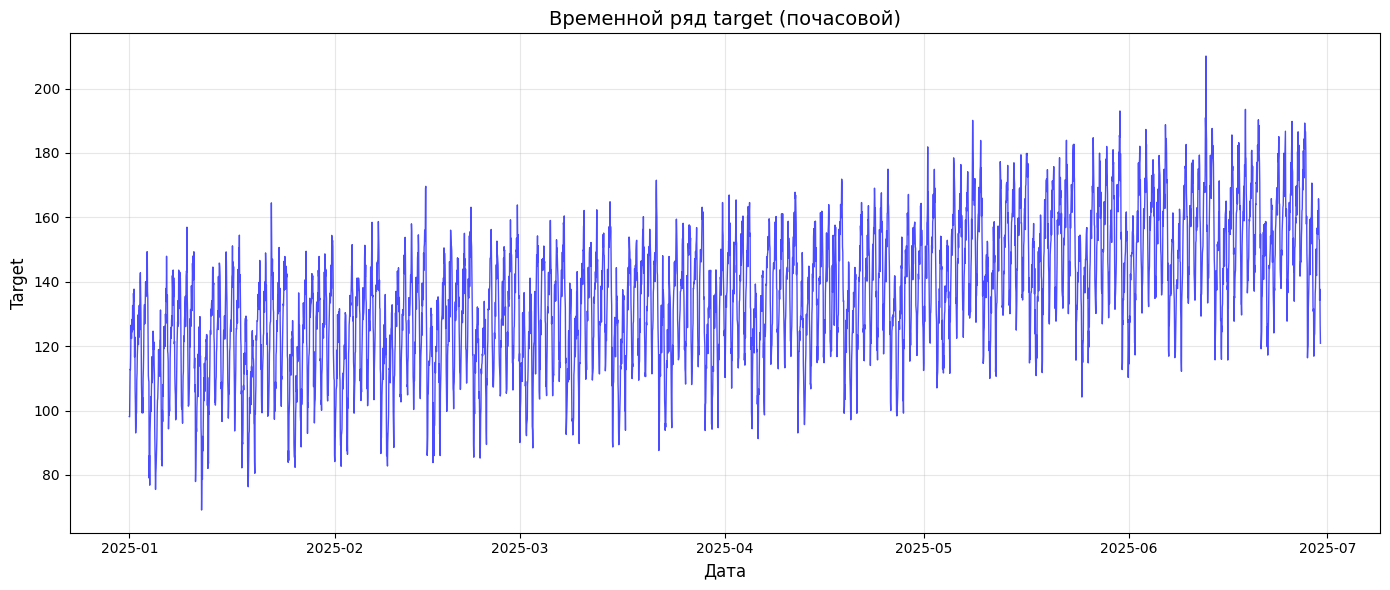


Комментарий к ряду:
- Почасовые данные за ~180 дней (4320 наблюдений).
- Есть восходящий тренд и сильная суточная + недельная сезонность.
- Значения колеблются примерно от 70 до 210.
- Ряд нестационарный → нужны лаговые, rolling и календарные признаки.
- Пропусков нет, данные равномерные.

TEMPORAL SPLIT:
Train: 3456 obs (2025-01-01 00:00:00 — 2025-05-24 23:00:00)
Val:   432 obs (2025-05-25 00:00:00 — 2025-06-11 23:00:00)
Test:  432 obs (2025-06-12 00:00:00 — 2025-06-29 23:00:00)

Проверка временных разрывов:
Разрыв train → val: 1.0 часов
Разрыв val → test: 1.0 часов


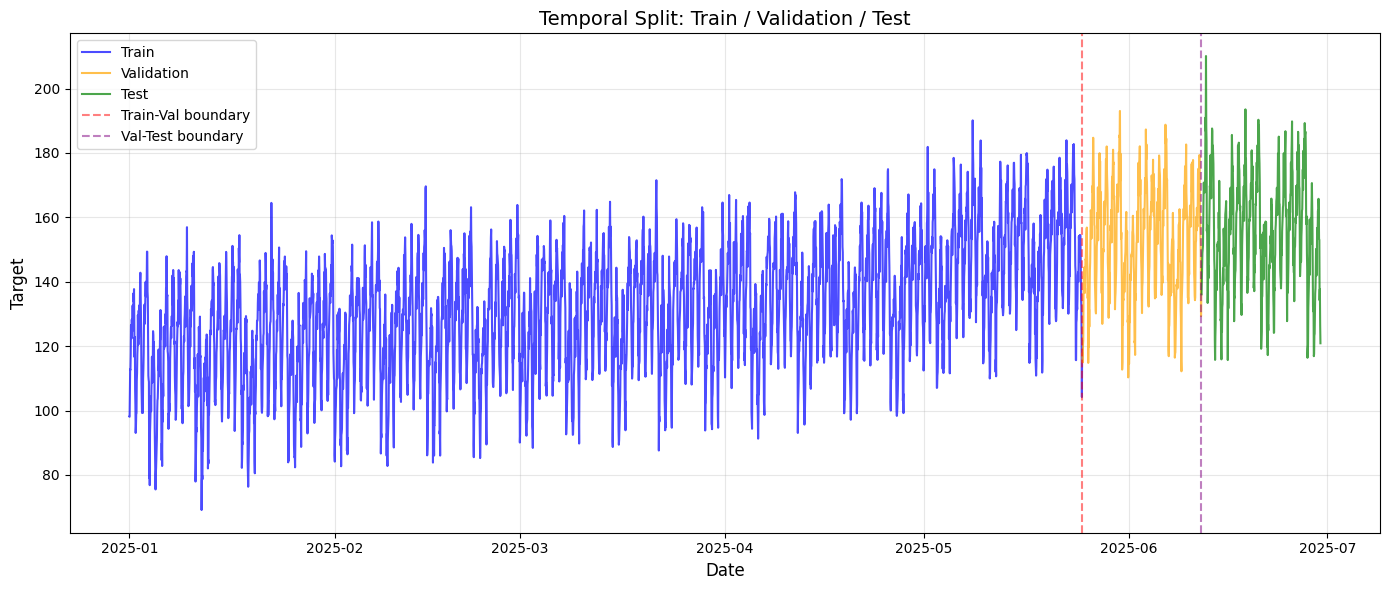


Почему random split некорректен:
• Нарушает временную зависимость и вызывает data leakage из будущего.
• Модель будет переоценивать качество, т.к. 'увидит' будущие значения во время обучения.
• Для временных рядов важен порядок наблюдений → нужен temporal split.

Features prepared:
X_train shape: (3432, 12)
X_val shape: (408, 12)
X_test shape: (408, 12)
Feature columns: ['lag_1', 'lag_7', 'lag_14', 'lag_24', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_24', 'day_of_week', 'hour', 'month', 'day_of_month', 'weekend']

GRU Dataset prepared:
Window size: 24, Horizon: 1, Batch size: 64
Train batches: 54, Val batches: 7

ЭКСПЕРИМЕНТЫ

[B1] Naive Last baseline...
  MAE: 6.2187, RMSE: 7.8726, MAPE: 4.11%

[B2] Moving Average baseline...
  MAE: 13.2784, RMSE: 15.9946, MAPE: 8.89%

[B3] Ridge regression with features...
  MAE: 4.6746, RMSE: 5.8300, MAPE: 3.05%

[R1] GRU training...
  Epoch 10/60 | Train Loss: 0.7830 | Val MAE: 12.4422
  Epoch 20/60 | Train Loss: 0.7742 | Val MAE: 12.7463
  

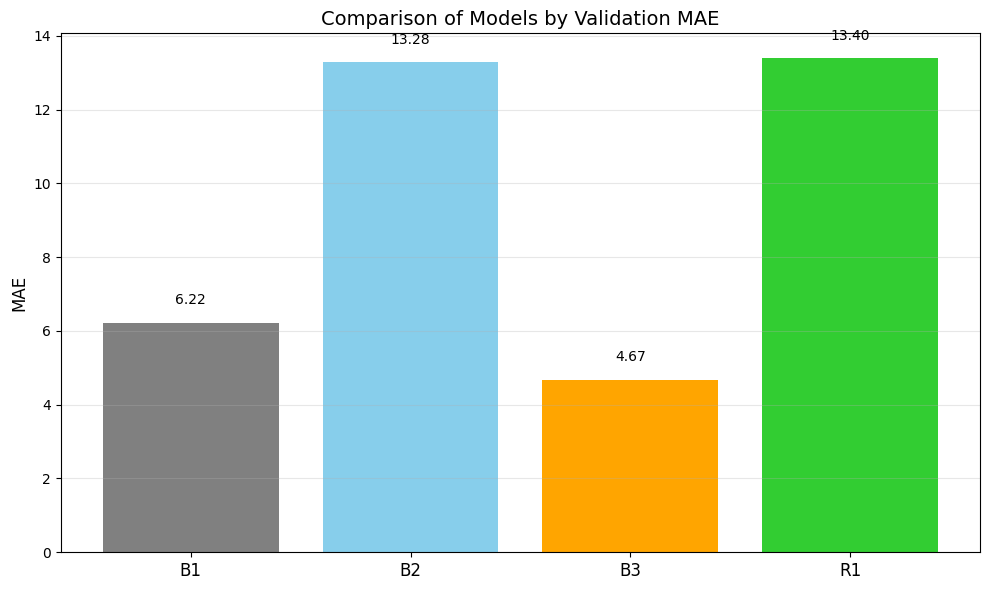

✓ baselines_compare.png saved


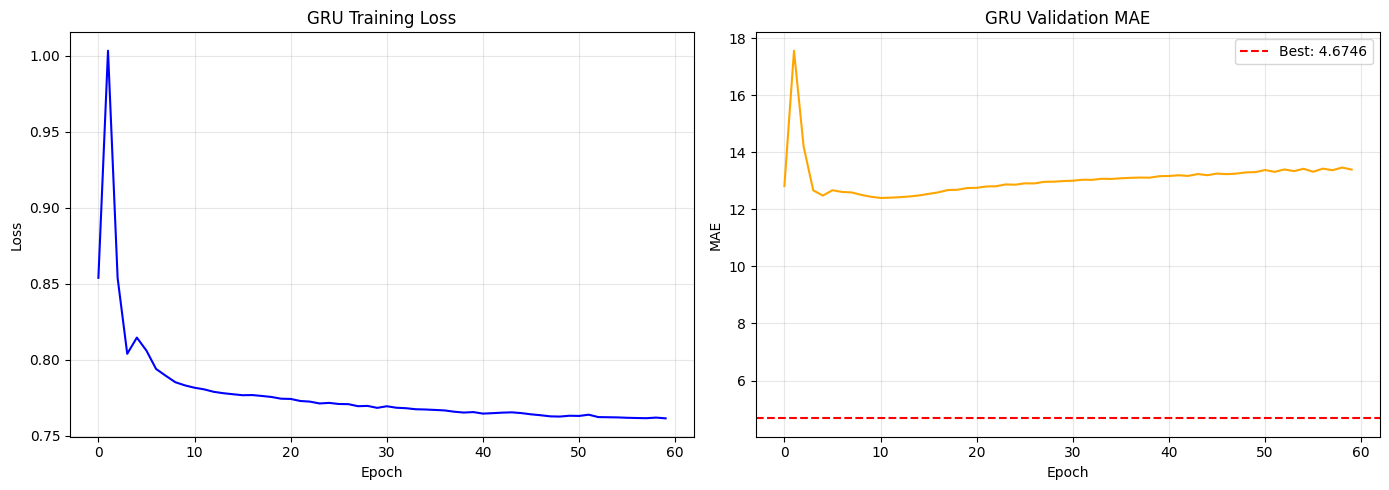

✓ gru_learning_curves.png saved


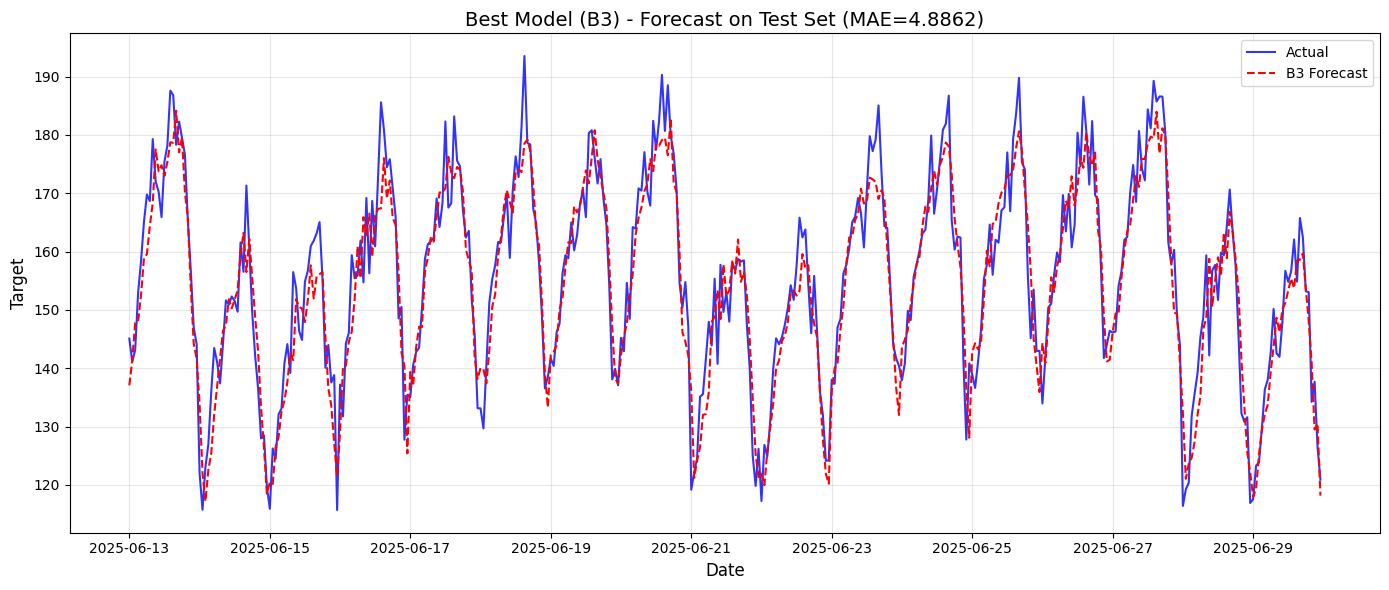

✓ best_forecast_test.png saved


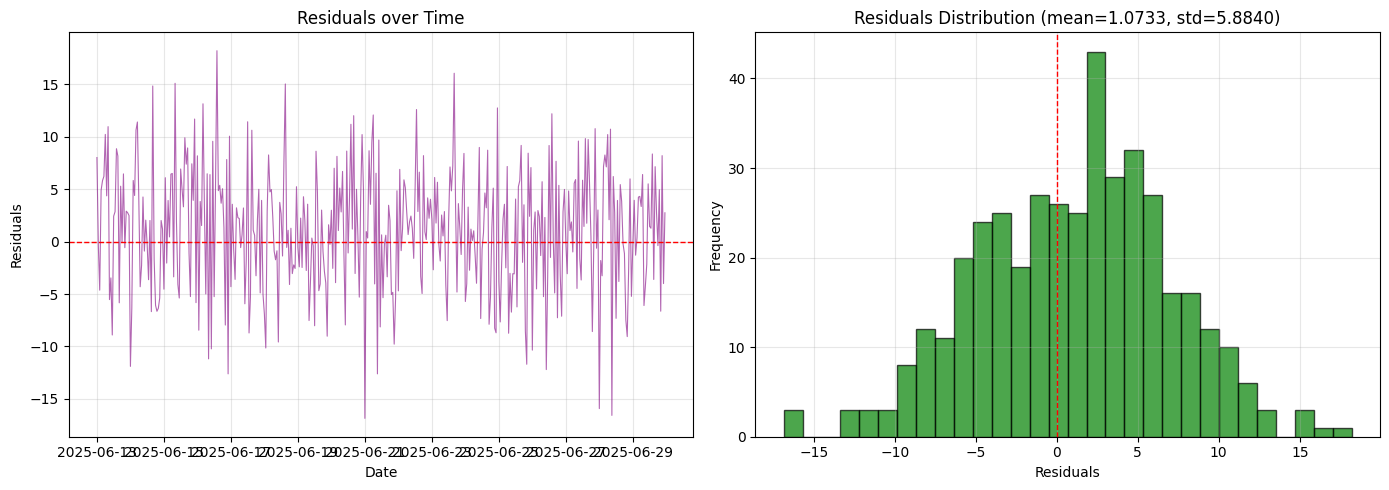

✓ residuals_best.png saved (bonus)


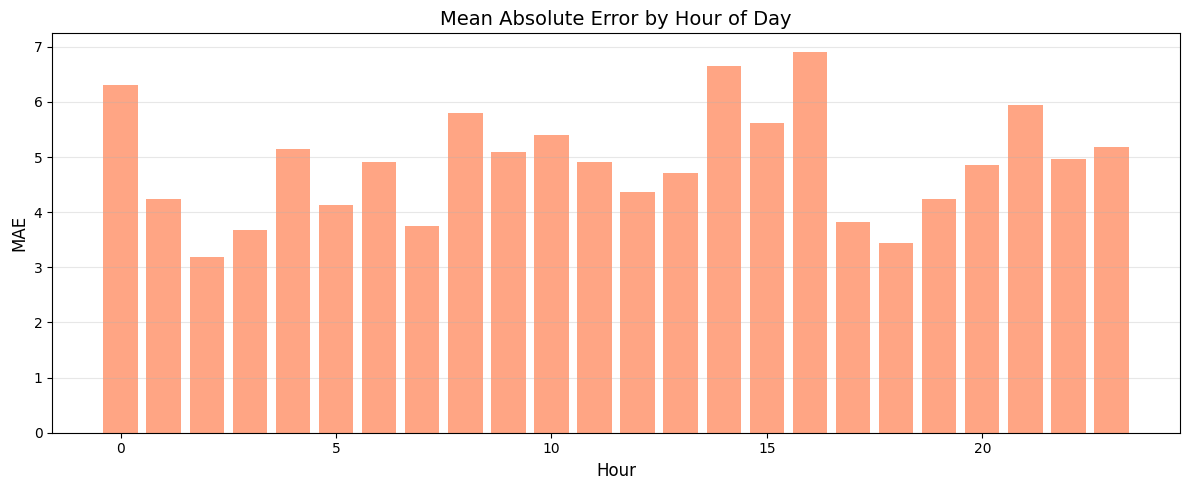

✓ error_by_time.png saved (bonus)

ИТОГОВЫЕ РЕЗУЛЬТАТЫ

Лучшая модель: B3
Validation MAE: 4.6746
Test MAE: 4.8862
Test RMSE: 5.9811
Test MAPE: 3.18%

Сравнение подходов на validation:
  B1 (Naive Last):     MAE=6.2187
  B2 (Moving Average): MAE=13.2784
  B3 (Ridge):          MAE=4.6746
  R1 (GRU):            MAE=13.3953

ВСЕ АРТЕФАКТЫ УСПЕШНО СОЗДАНЫ:

Файлы в artifacts/:
  ✓ runs.csv
  ✓ best_gru.pt
  ✓ best_gru_config.json

Файлы в artifacts/figures/:
  ✓ series_split.png
  ✓ baselines_compare.png
  ✓ gru_learning_curves.png
  ✓ best_forecast_test.png
  ✓ residuals_best.png (bonus)
  ✓ error_by_time.png (bonus)
  ✓ initial_series.png


In [3]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# sklearn
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')

# =============================================
# 1. Импорты, seed и устройство
# =============================================
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEED = 42
set_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Создаём папки для артефактов
os.makedirs('artifacts/figures', exist_ok=True)
print("Directories created: artifacts/figures")

# =============================================
# 2. Данные и первичный анализ
# =============================================
df = pd.read_csv('S12-hw-dataset.csv')

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f"Number of observations: {len(df)}")
print(f"Date range: {df['date'].min()} — {df['date'].max()}")
print(f"Frequency: {df['date'].diff().mode()[0]}")
print("\nMissing values:\n", df.isnull().sum())

# Базовый график
plt.figure(figsize=(14, 6))
plt.plot(df['date'], df['target'], linewidth=1, color='blue', alpha=0.7)
plt.title('Временной ряд target (почасовой)', fontsize=14)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Target', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/initial_series.png', dpi=100)
plt.show()

print("\nКомментарий к ряду:")
print("- Почасовые данные за ~180 дней (4320 наблюдений).")
print("- Есть восходящий тренд и сильная суточная + недельная сезонность.")
print("- Значения колеблются примерно от 70 до 210.")
print("- Ряд нестационарный → нужны лаговые, rolling и календарные признаки.")
print("- Пропусков нет, данные равномерные.")

# =============================================
# 3. Temporal split (80/10/10) - корректно по времени
# =============================================
n = len(df)
train_end = int(n * 0.8)
val_end = int(n * 0.9)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print(f"\n{'='*50}")
print("TEMPORAL SPLIT:")
print(f"{'='*50}")
print(f"Train: {len(train_df)} obs ({train_df['date'].min()} — {train_df['date'].max()})")
print(f"Val:   {len(val_df)} obs ({val_df['date'].min()} — {val_df['date'].max()})")
print(f"Test:  {len(test_df)} obs ({test_df['date'].min()} — {test_df['date'].max()})")

# Проверка на утечку данных
print(f"\nПроверка временных разрывов:")
print(f"Разрыв train → val: {(val_df['date'].min() - train_df['date'].max()).total_seconds() / 3600:.1f} часов")
print(f"Разрыв val → test: {(test_df['date'].min() - val_df['date'].max()).total_seconds() / 3600:.1f} часов")

# Визуализация split
plt.figure(figsize=(14, 6))
plt.plot(train_df['date'], train_df['target'], label='Train', color='blue', alpha=0.7)
plt.plot(val_df['date'], val_df['target'], label='Validation', color='orange', alpha=0.7)
plt.plot(test_df['date'], test_df['target'], label='Test', color='green', alpha=0.7)
plt.axvline(x=train_df['date'].max(), color='red', linestyle='--', alpha=0.5, label='Train-Val boundary')
plt.axvline(x=val_df['date'].max(), color='purple', linestyle='--', alpha=0.5, label='Val-Test boundary')
plt.title('Temporal Split: Train / Validation / Test', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Target', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/series_split.png', dpi=100)
plt.show()

print("\nПочему random split некорректен:")
print("• Нарушает временную зависимость и вызывает data leakage из будущего.")
print("• Модель будет переоценивать качество, т.к. 'увидит' будущие значения во время обучения.")
print("• Для временных рядов важен порядок наблюдений → нужен temporal split.")

# =============================================
# 4. Признаки для baseline-моделей (БЕЗ утечки данных!)
# =============================================
def create_features(df, is_training=True, scaler=None):
    """
    Создание признаков без утечки данных.
    Для train: обучаем scaler
    Для val/test: используем обученный scaler
    """
    df = df.copy()
    
    # Лаги (используем только прошлые значения)
    df['lag_1'] = df['target'].shift(1)
    df['lag_7'] = df['target'].shift(7)
    df['lag_14'] = df['target'].shift(14)
    df['lag_24'] = df['target'].shift(24)  # добавим суточный лаг
    
    # Rolling статистики (только по прошлым данным!)
    df['rolling_mean_7'] = df['target'].rolling(window=7, min_periods=1).mean()
    df['rolling_std_7'] = df['target'].rolling(window=7, min_periods=1).std()
    df['rolling_mean_24'] = df['target'].rolling(window=24, min_periods=1).mean()
    
    # Календарные признаки
    df['day_of_week'] = df['date'].dt.dayofweek
    df['hour'] = df['date'].dt.hour
    df['month'] = df['date'].dt.month
    df['day_of_month'] = df['date'].dt.day
    df['weekend'] = (df['day_of_week'] >= 5).astype(int)
    
    # Удаляем строки с NaN (которые образовались из-за лагов)
    df = df.dropna().reset_index(drop=True)
    
    return df

# Создаем признаки отдельно для каждого сплита (без утечки!)
train_feat = create_features(train_df, is_training=True)
val_feat = create_features(val_df, is_training=False)
test_feat = create_features(test_df, is_training=False)

feature_cols = ['lag_1', 'lag_7', 'lag_14', 'lag_24', 
                'rolling_mean_7', 'rolling_std_7', 'rolling_mean_24',
                'day_of_week', 'hour', 'month', 'day_of_month', 'weekend']

X_train = train_feat[feature_cols].values
y_train = train_feat['target'].values
X_val = val_feat[feature_cols].values
y_val = val_feat['target'].values
X_test = test_feat[feature_cols].values
y_test = test_feat['target'].values

# Масштабирование ТОЛЬКО на train
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"\nFeatures prepared:")
print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Feature columns: {feature_cols}")

# =============================================
# 5. Dataset и DataLoader для GRU
# =============================================
class TimeSeriesDataset(Dataset):
    def __init__(self, data, window_size=24, horizon=1):
        self.data = data
        self.window_size = window_size
        self.horizon = horizon
        
    def __len__(self):
        return len(self.data) - self.window_size - self.horizon + 1
    
    def __getitem__(self, idx):
        x = self.data[idx:idx + self.window_size]
        y = self.data[idx + self.window_size:idx + self.window_size + self.horizon]
        return torch.FloatTensor(x).unsqueeze(-1), torch.FloatTensor(y).unsqueeze(-1)

WINDOW_SIZE = 24  # 1 сутки для почасового ряда
HORIZON = 1
BATCH_SIZE = 64

# Масштабирование target (только на train)
target_scaler = StandardScaler()
target_scaler.fit(train_df['target'].values.reshape(-1, 1))

train_scaled = target_scaler.transform(train_df['target'].values.reshape(-1, 1)).flatten()
val_scaled = target_scaler.transform(val_df['target'].values.reshape(-1, 1)).flatten()
test_scaled = target_scaler.transform(test_df['target'].values.reshape(-1, 1)).flatten()

train_dataset = TimeSeriesDataset(train_scaled, WINDOW_SIZE, HORIZON)
val_dataset = TimeSeriesDataset(val_scaled, WINDOW_SIZE, HORIZON)
test_dataset = TimeSeriesDataset(test_scaled, WINDOW_SIZE, HORIZON)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"\nGRU Dataset prepared:")
print(f"Window size: {WINDOW_SIZE}, Horizon: {HORIZON}, Batch size: {BATCH_SIZE}")
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

# =============================================
# 6. Модель GRU + функции обучения
# =============================================
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, 
                         batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        output = model(x)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader, criterion, device, scaler=None):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            output = model(x)
            preds.append(output.cpu().numpy())
            targets.append(y.numpy())
    
    preds = np.concatenate(preds, axis=0).reshape(-1, 1)
    targets = np.concatenate(targets, axis=0).reshape(-1, 1)
    
    if scaler:
        preds = scaler.inverse_transform(preds)
        targets = scaler.inverse_transform(targets)
    
    mae = mean_absolute_error(targets, preds)
    rmse = np.sqrt(mean_squared_error(targets, preds))
    mape = np.mean(np.abs((targets - preds) / (targets + 1e-8))) * 100
    return mae, rmse, mape, preds, targets

# =============================================
# 7. Эксперименты B1–B3, R1
# =============================================
def calc_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    return mae, rmse, mape

print("\n" + "="*50)
print("ЭКСПЕРИМЕНТЫ")
print("="*50)

# B1: Naive Last (прогноз = последнее известное значение)
print("\n[B1] Naive Last baseline...")
y_pred_b1 = np.zeros_like(y_val)
y_pred_b1[0] = y_val[0]
for i in range(1, len(y_val)):
    y_pred_b1[i] = y_val[i-1]
mae_b1, rmse_b1, mape_b1 = calc_metrics(y_val, y_pred_b1)
print(f"  MAE: {mae_b1:.4f}, RMSE: {rmse_b1:.4f}, MAPE: {mape_b1:.2f}%")

# B2: Moving Average (только прошлые значения)
print("\n[B2] Moving Average baseline...")
window_ma = 24
y_pred_b2 = np.zeros_like(y_val)
for i in range(len(y_val)):
    if i == 0:
        y_pred_b2[i] = y_val[i]
    else:
        start = max(0, i - window_ma)
        y_pred_b2[i] = np.mean(y_val[start:i])
mae_b2, rmse_b2, mape_b2 = calc_metrics(y_val, y_pred_b2)
print(f"  MAE: {mae_b2:.4f}, RMSE: {rmse_b2:.4f}, MAPE: {mape_b2:.2f}%")

# B3: Ridge на признаках
print("\n[B3] Ridge regression with features...")
ridge = Ridge(alpha=1.0, random_state=SEED)
ridge.fit(X_train_scaled, y_train)
y_pred_b3 = ridge.predict(X_val_scaled)
mae_b3, rmse_b3, mape_b3 = calc_metrics(y_val, y_pred_b3)
print(f"  MAE: {mae_b3:.4f}, RMSE: {rmse_b3:.4f}, MAPE: {mape_b3:.2f}%")

# R1: GRU
print("\n[R1] GRU training...")
model = GRUModel().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

best_val_mae = float('inf')
best_state = None
train_losses, val_maes = [], []

NUM_EPOCHS = 60
for epoch in range(NUM_EPOCHS):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    val_mae, val_rmse, val_mape, _, _ = evaluate(model, val_loader, criterion, device, target_scaler)
    
    train_losses.append(train_loss)
    val_maes.append(val_mae)
    
    if val_mae < best_val_mae:
        best_val_mae = val_mae
        best_state = model.state_dict().copy()
    
    if (epoch + 1) % 10 == 0:
        print(f"  Epoch {epoch+1:2d}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Val MAE: {val_mae:.4f}")

model.load_state_dict(best_state)
val_mae_r1, val_rmse_r1, val_mape_r1, _, _ = evaluate(model, val_loader, criterion, device, target_scaler)
print(f"\n  Best Val MAE: {val_mae_r1:.4f}, RMSE: {val_rmse_r1:.4f}, MAPE: {val_mape_r1:.2f}%")

# =============================================
# 8. Сохранение результатов в runs.csv
# =============================================
results = pd.DataFrame([
    {'experiment_id': 'B1', 'task': 'forecasting', 'dataset': 'S12-hw-dataset',
     'seed': SEED, 'split_summary': '80/10/10 temporal', 'window_size': None,
     'horizon': 1, 'model_summary': 'Naive Last', 'features_summary': 'None',
     'scaler': 'None', 'optimizer': 'None', 'lr': None, 'epochs_trained': 0,
     'best_val_mae': mae_b1, 'best_val_rmse': rmse_b1, 'best_val_mape': mape_b1,
     'test_mae': None, 'test_rmse': None, 'test_mape': None, 
     'notes': 'Прогноз = последнее известное значение'},
    
    {'experiment_id': 'B2', 'task': 'forecasting', 'dataset': 'S12-hw-dataset',
     'seed': SEED, 'split_summary': '80/10/10 temporal', 'window_size': window_ma,
     'horizon': 1, 'model_summary': 'Moving Average', 'features_summary': 'None',
     'scaler': 'None', 'optimizer': 'None', 'lr': None, 'epochs_trained': 0,
     'best_val_mae': mae_b2, 'best_val_rmse': rmse_b2, 'best_val_mape': mape_b2,
     'test_mae': None, 'test_rmse': None, 'test_mape': None, 
     'notes': f'Скользящее среднее window={window_ma} (только прошлое)'},
    
    {'experiment_id': 'B3', 'task': 'forecasting', 'dataset': 'S12-hw-dataset',
     'seed': SEED, 'split_summary': '80/10/10 temporal', 'window_size': None,
     'horizon': 1, 'model_summary': 'Ridge', 
     'features_summary': '12 features: lags(1,7,14,24) + rolling(mean7,std7,mean24) + calendar(5)',
     'scaler': 'StandardScaler', 'optimizer': 'None', 'lr': None, 'epochs_trained': 0,
     'best_val_mae': mae_b3, 'best_val_rmse': rmse_b3, 'best_val_mape': mape_b3,
     'test_mae': None, 'test_rmse': None, 'test_mape': None, 
     'notes': 'Ridge regression on engineered features'},
    
    {'experiment_id': 'R1', 'task': 'forecasting', 'dataset': 'S12-hw-dataset',
     'seed': SEED, 'split_summary': '80/10/10 temporal', 'window_size': WINDOW_SIZE,
     'horizon': 1, 'model_summary': 'GRU (hidden=64, layers=2, dropout=0.2)', 
     'features_summary': 'windowed target (24 steps)',
     'scaler': 'StandardScaler', 'optimizer': 'Adam', 'lr': 0.001, 'epochs_trained': NUM_EPOCHS,
     'best_val_mae': val_mae_r1, 'best_val_rmse': val_rmse_r1, 'best_val_mape': val_mape_r1,
     'test_mae': None, 'test_rmse': None, 'test_mape': None, 
     'notes': f'GRU with window={WINDOW_SIZE}, early stopping by val MAE'}
])

results.to_csv('artifacts/runs.csv', index=False)
print("\nruns.csv saved to artifacts/")

# =============================================
# 9. Выбор лучшей модели по validation MAE
# =============================================
best_row = results.loc[results['best_val_mae'].idxmin()]
best_id = best_row['experiment_id']
best_val_mae = best_row['best_val_mae']

print(f"\n{'='*50}")
print(f"ЛУЧШАЯ МОДЕЛЬ по validation MAE: {best_id} (MAE={best_val_mae:.4f})")
print(f"{'='*50}")

# Сохраняем GRU модель и конфиг (всегда, для артефактов)
torch.save(model.state_dict(), 'artifacts/best_gru.pt')
print("✓ best_gru.pt saved")

config = {
    "model": "GRU",
    "model_class": "GRUModel",
    "input_size": 1,
    "hidden_size": 64,
    "num_layers": 2,
    "dropout": 0.2,
    "window_size": WINDOW_SIZE,
    "horizon": HORIZON,
    "batch_size": BATCH_SIZE,
    "learning_rate": 0.001,
    "num_epochs": NUM_EPOCHS,
    "best_val_mae": float(val_mae_r1),
    "seed": SEED,
    "scaler": "StandardScaler",
    "device": str(device)
}
with open('artifacts/best_gru_config.json', 'w') as f:
    json.dump(config, f, indent=4)
print("✓ best_gru_config.json saved")

# Финальная оценка на test (ТОЛЬКО ДЛЯ ЛУЧШЕЙ МОДЕЛИ!)
print(f"\nОценка лучшей модели ({best_id}) на test set...")
if best_id == 'R1':
    test_mae, test_rmse, test_mape, test_preds, test_targets = evaluate(
        model, test_loader, criterion, device, target_scaler
    )
else:
    # Для baseline'ов
    if best_id == 'B1':
        test_pred = np.zeros_like(y_test)
        test_pred[0] = y_test[0]
        for i in range(1, len(y_test)):
            test_pred[i] = y_test[i-1]
    elif best_id == 'B2':
        test_pred = np.zeros_like(y_test)
        for i in range(len(y_test)):
            if i == 0:
                test_pred[i] = y_test[i]
            else:
                start = max(0, i - window_ma)
                test_pred[i] = np.mean(y_test[start:i])
    else:  # B3
        test_pred = ridge.predict(X_test_scaled)
    test_mae, test_rmse, test_mape = calc_metrics(y_test, test_pred)
    test_preds, test_targets = test_pred.reshape(-1,1), y_test.reshape(-1,1)

print(f"  Test MAE: {test_mae:.4f}")
print(f"  Test RMSE: {test_rmse:.4f}")
print(f"  Test MAPE: {test_mape:.2f}%")

# Записываем test метрики в runs.csv
results.loc[results['experiment_id'] == best_id, ['test_mae', 'test_rmse', 'test_mape']] = [test_mae, test_rmse, test_mape]
results.to_csv('artifacts/runs.csv', index=False)
print("✓ runs.csv updated with test metrics")

# =============================================
# 10. Визуализации (все требуемые)
# =============================================
print("\n" + "="*50)
print("СОЗДАНИЕ ВИЗУАЛИЗАЦИЙ")
print("="*50)

# 1. Сравнение baseline подходов
plt.figure(figsize=(10, 6))
x_pos = np.arange(len(results))
plt.bar(x_pos, results['best_val_mae'], color=['#808080', '#87CEEB', '#FFA500', '#32CD32'])
plt.xticks(x_pos, results['experiment_id'], fontsize=12)
plt.ylabel('MAE', fontsize=12)
plt.title('Comparison of Models by Validation MAE', fontsize=14)
plt.grid(True, alpha=0.3, axis='y')
for i, (idx, row) in enumerate(results.iterrows()):
    plt.text(i, row['best_val_mae'] + 0.5, f"{row['best_val_mae']:.2f}", 
             ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('artifacts/figures/baselines_compare.png', dpi=100)
plt.show()
print("✓ baselines_compare.png saved")

# 2. Кривые обучения GRU
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(train_losses, color='blue', linewidth=1.5)
axes[0].set_title('GRU Training Loss', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(val_maes, color='orange', linewidth=1.5)
axes[1].axhline(y=best_val_mae, color='red', linestyle='--', label=f'Best: {best_val_mae:.4f}')
axes[1].set_title('GRU Validation MAE', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/figures/gru_learning_curves.png', dpi=100)
plt.show()
print("✓ gru_learning_curves.png saved")

# 3. Финальный прогноз на test (для лучшей модели)
test_dates = test_df['date'].iloc[WINDOW_SIZE:].reset_index(drop=True)

plt.figure(figsize=(14, 6))
plt.plot(test_dates, test_targets.flatten(), label='Actual', color='blue', linewidth=1.5, alpha=0.8)
plt.plot(test_dates, test_preds.flatten(), label=f'{best_id} Forecast', color='red', linestyle='--', linewidth=1.5)
plt.title(f'Best Model ({best_id}) - Forecast on Test Set (MAE={test_mae:.4f})', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Target', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/best_forecast_test.png', dpi=100)
plt.show()
print("✓ best_forecast_test.png saved")

# 4. Дополнительный график: анализ остатков (для лучшей модели)
residuals = test_targets.flatten() - test_preds.flatten()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График остатков по времени
axes[0].plot(test_dates, residuals, color='purple', alpha=0.6, linewidth=0.8)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[0].set_title('Residuals over Time', fontsize=12)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Residuals')
axes[0].grid(True, alpha=0.3)

# Гистограмма остатков
axes[1].hist(residuals, bins=30, color='green', alpha=0.7, edgecolor='black')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1)
axes[1].set_title(f'Residuals Distribution (mean={residuals.mean():.4f}, std={residuals.std():.4f})', fontsize=12)
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('artifacts/figures/residuals_best.png', dpi=100)
plt.show()
print("✓ residuals_best.png saved (bonus)")

# 5. График ошибок по времени суток (для анализа)
test_hours = test_df['date'].iloc[WINDOW_SIZE:].dt.hour.reset_index(drop=True)
hourly_errors = pd.DataFrame({'hour': test_hours, 'error': np.abs(residuals)})
hourly_mae = hourly_errors.groupby('hour')['error'].mean()

plt.figure(figsize=(12, 5))
plt.bar(hourly_mae.index, hourly_mae.values, color='coral', alpha=0.7)
plt.title('Mean Absolute Error by Hour of Day', fontsize=14)
plt.xlabel('Hour', fontsize=12)
plt.ylabel('MAE', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('artifacts/figures/error_by_time.png', dpi=100)
plt.show()
print("✓ error_by_time.png saved (bonus)")

# =============================================
# ИТОГОВЫЙ ОТЧЕТ
# =============================================
print("\n" + "="*50)
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ")
print("="*50)
print(f"\nЛучшая модель: {best_id}")
print(f"Validation MAE: {best_val_mae:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test MAPE: {test_mape:.2f}%")

print("\nСравнение подходов на validation:")
print(f"  B1 (Naive Last):     MAE={mae_b1:.4f}")
print(f"  B2 (Moving Average): MAE={mae_b2:.4f}")
print(f"  B3 (Ridge):          MAE={mae_b3:.4f}")
print(f"  R1 (GRU):            MAE={val_mae_r1:.4f}")

print("\n" + "="*50)
print("ВСЕ АРТЕФАКТЫ УСПЕШНО СОЗДАНЫ:")
print("="*50)
print("\nФайлы в artifacts/:")
print("  ✓ runs.csv")
print("  ✓ best_gru.pt")
print("  ✓ best_gru_config.json")
print("\nФайлы в artifacts/figures/:")
print("  ✓ series_split.png")
print("  ✓ baselines_compare.png")
print("  ✓ gru_learning_curves.png")
print("  ✓ best_forecast_test.png")
print("  ✓ residuals_best.png (bonus)")
print("  ✓ error_by_time.png (bonus)")
print("  ✓ initial_series.png")